# Gold New-Data Simulation for PyTorch CNN-BiLSTM

This notebook simulates **new data** using the **same preprocessing logic** as the training pipeline you shared:

- load saved PyTorch model artifacts
- concatenate historical data and new data
- rebuild the return-based working dataframe
- scale with the saved scalers
- create sequences using the saved `lookback`
- predict **next-step return**
- convert predicted return back to **absolute gold price**

This matches the training code logic where the model predicts `target_t_plus_1` from percentage returns, then reconstructs price as:

`predicted_price = P_t_abs * (1 + predicted_return)`

## 1) Paths and user settings

Update these paths first.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

try:
    import exchange_calendars as xcals
except Exception:
    xcals = None

warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("exchange_calendars available:", xcals is not None)

# =========================
# 1) PATHS
# =========================
BASE_DIR = r"/content/drive/MyDrive/IPYNB SIMULATION/models/gold_RRL_interpolate/seed_2"
ORIGINAL_HISTORY_PATH = r"/content/drive/MyDrive/ResearchTestingGold/Silver gold Research/Silver gold/CleanDATA_2026_study_aligned_local_interpolation_only/gold_RRL_interpolate.csv"
NEW_DATA_PATH = r"/content/drive/MyDrive/IPYNB SIMULATION/CleanDATA_2025_05_01_to_2025_12_01_gold_silver_tables_only/gold_RRL_interpolate.csv"

MODEL_PATH = os.path.join(BASE_DIR, "cnn_bilstm_seed2.pth")
X_SCALER_PATH = os.path.join(BASE_DIR, "x_scaler.pkl")
Y_SCALER_PATH = os.path.join(BASE_DIR, "y_scaler.pkl")
METADATA_PATH = os.path.join(BASE_DIR, "model_metadata.json")

DATE_COL = "Date"
RAW_TARGET_COL = "Gold_Futures"
SIM_START = "2025-05-01"
SIM_END = "2025-11-28"
DEFAULT_QUERY_DATE = "2025-08-15"

TARGET_CALENDAR_NAME = "COMEX"

# Manual holiday overrides aligned with the official test-set notebook.
# Juneteenth is added because some exchange calendar versions do not surface it consistently.
COMEX_HOLIDAY_MANUAL_OVERRIDES = pd.DataFrame({
    "Date": pd.to_datetime([
        "2022-06-20",
        "2023-06-19",
        "2024-06-19",
        "2025-06-19",
    ]),
    "holiday_name": [
        "Juneteenth National Independence Day",
        "Juneteenth National Independence Day",
        "Juneteenth National Independence Day",
        "Juneteenth National Independence Day",
    ],
    "holiday_type": [
        "manual_override",
        "manual_override",
        "manual_override",
        "manual_override",
    ],
    "session_effect": [
        "holiday_schedule_notice",
        "holiday_schedule_notice",
        "holiday_schedule_notice",
        "holiday_schedule_notice",
    ],
    "close_time": [pd.NaT, pd.NaT, pd.NaT, pd.NaT],
    "open_time": [pd.NaT, pd.NaT, pd.NaT, pd.NaT],
    "tag_source": [
        "manual_cme_notice",
        "manual_cme_notice",
        "manual_cme_notice",
        "manual_cme_notice",
    ],
    "source_note": [
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
        "Juneteenth holiday schedule manually added because exchange_calendars did not surface metadata for this date.",
    ],
})


Using device: cpu
exchange_calendars available: False


## 2) Model class

This must match the architecture used during training.

In [ ]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, input_shape, params):
        super(CNN_BiLSTM, self).__init__()
        in_channels = input_shape[1]
        dr = params["dropout_rate"]

        self.conv1 = nn.Conv1d(
            in_channels=in_channels,
            out_channels=params["filters"],
            kernel_size=params["kernel_size"],
            padding=params["kernel_size"] - 1
        )
        self.relu = nn.ReLU()
        self.bn1 = nn.BatchNorm1d(params["filters"])
        self.spatial_dropout = nn.Dropout1d(p=dr)

        self.lstm1 = nn.LSTM(
            input_size=params["filters"],
            hidden_size=params["lstm_units"],
            batch_first=True,
            bidirectional=True
        )
        self.dropout1 = nn.Dropout(dr)

        lstm2_units = max(16, params["lstm_units"] // 2)
        self.lstm2 = nn.LSTM(
            input_size=params["lstm_units"] * 2,
            hidden_size=lstm2_units,
            batch_first=True,
            bidirectional=True
        )
        self.dropout2 = nn.Dropout(dr)

        self.fc1 = nn.Linear(lstm2_units * 2, params["dense_units"])
        self.fc_dropout = nn.Dropout(dr)
        self.out = nn.Linear(params["dense_units"], 1)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv1(x)
        if self.conv1.padding[0] > 0:
            x = x[:, :, :-self.conv1.padding[0]]
        x = self.relu(x)
        x = self.bn1(x)
        x = self.spatial_dropout(x)

        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x = self.dropout1(x)

        _, (h_n, _) = self.lstm2(x)
        h_f = h_n[0, :, :]
        h_b = h_n[1, :, :]
        x = torch.cat((h_f, h_b), dim=1)

        x = self.dropout2(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc_dropout(x)
        x = self.out(x)
        return x

## 3) Helpers

In [ ]:
def infer_model_params_from_state_dict(state_dict):
    return {
        "filters": int(state_dict["conv1.weight"].shape[0]),
        "kernel_size": int(state_dict["conv1.weight"].shape[2]),
        "lstm_units": int(state_dict["lstm1.weight_ih_l0"].shape[0] // 4),
        "dense_units": int(state_dict["fc1.weight"].shape[0]),
        "dropout_rate": 0.0,  # dropout is inactive during eval()
    }

def create_sequences(X_df, y_df, lookback, abs_y_df=None):
    X_values = X_df.values
    y_values = y_df.values.reshape(-1)

    if abs_y_df is not None:
        abs_y_values = abs_y_df.values.reshape(-1)

    X_seq, y_seq, abs_y_seq = [], [], []
    for i in range(lookback, len(X_df)):
        X_seq.append(X_values[i - lookback:i, :])
        y_seq.append(y_values[i])
        if abs_y_df is not None:
            abs_y_seq.append(abs_y_values[i])

    if abs_y_df is not None:
        return np.array(X_seq), np.array(y_seq), np.array(abs_y_seq)
    return np.array(X_seq), np.array(y_seq)

def load_and_prepare_raw_dataframe(csv_path, date_col):
    df = pd.read_csv(csv_path)

    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' not found in {csv_path}")

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col).reset_index(drop=True)
    return df

def _empty_holiday_frame():
    return pd.DataFrame(
        columns=[
            "Date",
            "holiday_name",
            "holiday_type",
            "session_effect",
            "close_time",
            "open_time",
            "tag_source",
            "source_note",
        ]
    )

def build_calendar_holiday_tables(calendar, start_date, end_date, manual_overrides=None):
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()

    def _frames_from_rules(rules, holiday_type, session_effect, close_time=pd.NaT, open_time=pd.NaT):
        frames = []
        for rule in rules:
            rule_dates = pd.DatetimeIndex(rule.dates(start, end))
            if len(rule_dates) == 0:
                continue
            frames.append(pd.DataFrame({
                "Date": rule_dates,
                "holiday_name": getattr(rule, "name", str(rule)),
                "holiday_type": holiday_type,
                "session_effect": session_effect,
                "close_time": close_time,
                "open_time": open_time,
                "tag_source": "exchange_calendars",
                "source_note": "Tagged from exchange_calendars holiday rules.",
            }))
        return frames

    full_frames = []
    regular_holiday_rules = getattr(getattr(calendar, "regular_holidays", None), "rules", [])
    full_frames.extend(
        _frames_from_rules(
            regular_holiday_rules,
            holiday_type="full_closure_regular",
            session_effect="closed",
        )
    )

    adhoc_dates = pd.DatetimeIndex(getattr(calendar, "adhoc_holidays", []))
    if len(adhoc_dates) > 0:
        adhoc_dates = adhoc_dates[(adhoc_dates >= start) & (adhoc_dates <= end)]
        if len(adhoc_dates) > 0:
            full_frames.append(pd.DataFrame({
                "Date": adhoc_dates,
                "holiday_name": "Ad hoc full-closure holiday",
                "holiday_type": "full_closure_adhoc",
                "session_effect": "closed",
                "close_time": pd.NaT,
                "open_time": pd.NaT,
                "tag_source": "exchange_calendars",
                "source_note": "Tagged from exchange_calendars ad hoc holiday list.",
            }))

    full_closures = pd.concat(full_frames, ignore_index=True) if full_frames else _empty_holiday_frame()

    def _special_frames(special_rules, session_effect):
        frames = []
        for tm, holiday_calendar in special_rules:
            rules = getattr(holiday_calendar, "rules", [])
            if rules:
                frames.extend(
                    _frames_from_rules(
                        rules,
                        holiday_type=session_effect,
                        session_effect=session_effect,
                        close_time=str(tm) if session_effect == "special_close" else pd.NaT,
                        open_time=str(tm) if session_effect == "special_open" else pd.NaT,
                    )
                )
            else:
                cal_dates = pd.DatetimeIndex(holiday_calendar.holidays(start, end))
                if len(cal_dates) == 0:
                    continue
                frames.append(pd.DataFrame({
                    "Date": cal_dates,
                    "holiday_name": f"{session_effect} holiday",
                    "holiday_type": session_effect,
                    "session_effect": session_effect,
                    "close_time": str(tm) if session_effect == "special_close" else pd.NaT,
                    "open_time": str(tm) if session_effect == "special_open" else pd.NaT,
                    "tag_source": "exchange_calendars",
                    "source_note": "Tagged from exchange_calendars special session rules.",
                }))
        return frames

    special_close_frames = _special_frames(getattr(calendar, "special_closes", []), "special_close")
    special_open_frames = _special_frames(getattr(calendar, "special_opens", []), "special_open")

    special_closes = pd.concat(special_close_frames, ignore_index=True) if special_close_frames else _empty_holiday_frame()
    special_opens = pd.concat(special_open_frames, ignore_index=True) if special_open_frames else _empty_holiday_frame()

    manual_df = _empty_holiday_frame()
    if manual_overrides is not None and len(manual_overrides) > 0:
        manual_df = manual_overrides.copy()
        manual_df["Date"] = pd.to_datetime(manual_df["Date"]).dt.normalize()
        manual_df = manual_df[(manual_df["Date"] >= start) & (manual_df["Date"] <= end)]

    holiday_schedule = pd.concat(
        [full_closures, special_closes, special_opens, manual_df],
        ignore_index=True
    )
    if not holiday_schedule.empty:
        holiday_schedule["Date"] = pd.to_datetime(holiday_schedule["Date"]).dt.normalize()
        holiday_schedule = (
            holiday_schedule
            .sort_values(["Date", "holiday_type", "holiday_name"])
            .drop_duplicates(subset=["Date", "holiday_type", "holiday_name"])
            .reset_index(drop=True)
        )

    return full_closures, special_closes, special_opens, manual_df, holiday_schedule

def nearest_available_forecast_bounds(query_date, available_dates):
    available_idx = pd.DatetimeIndex(pd.to_datetime(available_dates)).normalize().sort_values().unique()
    query_date = pd.Timestamp(query_date).normalize()

    prev_dates = available_idx[available_idx < query_date]
    next_dates = available_idx[available_idx > query_date]

    prev_date = prev_dates.max() if len(prev_dates) else pd.NaT
    next_date = next_dates.min() if len(next_dates) else pd.NaT
    return prev_date, next_date

def build_unavailable_forecast_dates(available_forecast_dates, start_date, end_date, calendar_name="COMEX", manual_overrides=None):
    start = pd.Timestamp(start_date).normalize()
    end = pd.Timestamp(end_date).normalize()
    available_idx = pd.DatetimeIndex(pd.to_datetime(available_forecast_dates)).normalize().sort_values().unique()
    daily_range = pd.date_range(start, end, freq="D")
    unavailable_idx = daily_range.difference(available_idx)

    rows = []
    holiday_schedule = _empty_holiday_frame()
    calendar_sessions = None

    if xcals is not None:
        calendar = xcals.get_calendar(calendar_name)
        calendar_sessions = pd.DatetimeIndex(calendar.sessions_in_range(start, end)).normalize()
        _, _, _, _, holiday_schedule = build_calendar_holiday_tables(
            calendar,
            start,
            end,
            manual_overrides=manual_overrides,
        )
        if not holiday_schedule.empty:
            holiday_schedule["Date"] = pd.to_datetime(holiday_schedule["Date"]).dt.normalize()

    for dt in unavailable_idx:
        dt = pd.Timestamp(dt).normalize()
        prev_date, next_date = nearest_available_forecast_bounds(dt, available_idx)

        schedule_rows = pd.DataFrame()
        if not holiday_schedule.empty:
            schedule_rows = holiday_schedule.loc[holiday_schedule["Date"] == dt].copy()

        if calendar_sessions is None:
            if dt.dayofweek >= 5:
                market_status = "non-market day"
                reason = "Weekend / not available in dataset"
            else:
                market_status = "not available in dataset"
                reason = "Date not present in forecast table"
        else:
            is_session = dt in calendar_sessions
            if not is_session:
                market_status = "non-market day"
                if not schedule_rows.empty:
                    reason = " | ".join(
                        schedule_rows["holiday_name"].astype(str) + " (" + schedule_rows["session_effect"].astype(str) + ")"
                    )
                elif dt.dayofweek >= 5:
                    reason = "Weekend / COMEX closed"
                else:
                    reason = "COMEX closed / no market session"
            else:
                market_status = "calendar session but unavailable in dataset"
                if not schedule_rows.empty:
                    reason = " | ".join(
                        schedule_rows["holiday_name"].astype(str) + " (" + schedule_rows["session_effect"].astype(str) + ")"
                    ) + " | date still unavailable in dataset"
                else:
                    reason = "Valid COMEX session but missing from forecast table"

        rows.append({
            "Date": dt,
            "market_status": market_status,
            "reason": reason,
            "nearest_previous_available_forecast": prev_date,
            "nearest_next_available_forecast": next_date,
        })

    unavailable_df = pd.DataFrame(rows).sort_values("Date").reset_index(drop=True)
    return unavailable_df

def build_simulation_table(historical_df, new_df, metadata, x_scaler, y_scaler, model):
    feature_cols = list(metadata["feature_cols"])
    lookback = int(metadata["lookback"])
    model_target_col = metadata["target_col"]

    required_cols = [DATE_COL] + feature_cols
    if RAW_TARGET_COL not in required_cols:
        required_cols.append(RAW_TARGET_COL)

    hist = historical_df[required_cols].copy()
    new = new_df[required_cols].copy()

    full_raw = pd.concat([hist, new], ignore_index=True)
    full_raw = (
        full_raw
        .drop_duplicates(subset=[DATE_COL], keep="last")
        .sort_values(DATE_COL)
        .reset_index(drop=True)
    )

    numeric_cols = [c for c in full_raw.columns if c != DATE_COL]
    for col in numeric_cols:
        full_raw[col] = pd.to_numeric(full_raw[col], errors="coerce")

    work = full_raw.copy().set_index(DATE_COL)

    ABS_P_T = "P_t_abs"
    ABS_TARGET_COL = "P_t_plus_1_abs"

    work[ABS_P_T] = work[RAW_TARGET_COL]

    returns_df = work[numeric_cols].pct_change().replace([np.inf, -np.inf], np.nan).dropna()
    returns_df[ABS_P_T] = work[ABS_P_T].loc[returns_df.index]

    returns_df[model_target_col] = returns_df[RAW_TARGET_COL].shift(-1)
    returns_df[ABS_TARGET_COL] = returns_df[ABS_P_T].shift(-1)
    returns_df["forecast_date"] = returns_df.index.to_series().shift(-1)

    returns_df = returns_df.dropna().reset_index()

    X_df = returns_df[feature_cols].copy()
    y_df = returns_df[[model_target_col]].copy()
    p_t_df = returns_df[[ABS_P_T]].copy()
    p_t_plus_1_df = returns_df[[ABS_TARGET_COL]].copy()

    X_scaled = pd.DataFrame(x_scaler.transform(X_df), columns=feature_cols)
    y_scaled = pd.DataFrame(y_scaler.transform(y_df), columns=[model_target_col])

    X_seq, y_seq, p_t_seq = create_sequences(X_scaled, y_scaled, lookback, abs_y_df=p_t_df)
    _, _, p_t_plus_1_seq = create_sequences(X_scaled, y_scaled, lookback, abs_y_df=p_t_plus_1_df)

    model.eval()
    with torch.no_grad():
        X_t = torch.tensor(X_seq, dtype=torch.float32).to(device)
        pred_scaled = model(X_t).cpu().numpy().reshape(-1, 1)

    pred_return = y_scaler.inverse_transform(pred_scaled).reshape(-1)
    actual_return = y_scaler.inverse_transform(y_seq.reshape(-1, 1)).reshape(-1)

    predicted_price = p_t_seq.reshape(-1) * (1 + pred_return)
    actual_price = p_t_plus_1_seq.reshape(-1)

    results_df = pd.DataFrame({
        "anchor_date": returns_df[DATE_COL].iloc[lookback:].reset_index(drop=True),
        "forecast_date": returns_df["forecast_date"].iloc[lookback:].reset_index(drop=True),
        "predicted_return": pred_return,
        "actual_return": actual_return,
        "predicted_price": predicted_price,
        "actual_price": actual_price,
        "absolute_error": np.abs(actual_price - predicted_price),
        "squared_error": (actual_price - predicted_price) ** 2,
    })

    return results_df, returns_df

def evaluate_window(results_df, start_date, end_date):
    picked = results_df[
        (results_df["forecast_date"] >= pd.Timestamp(start_date)) &
        (results_df["forecast_date"] <= pd.Timestamp(end_date))
    ].copy()

    if picked.empty:
        raise ValueError("No forecast rows found inside the selected simulation window.")

    rmse = np.sqrt(mean_squared_error(picked["actual_price"], picked["predicted_price"]))
    mae = mean_absolute_error(picked["actual_price"], picked["predicted_price"])
    r2 = r2_score(picked["actual_price"], picked["predicted_price"])

    return picked, {
        "rows": int(len(picked)),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }

def lookup_forecast_by_date(results_df, query_date):
    q = pd.Timestamp(query_date).normalize()
    tmp = results_df.copy()
    tmp["forecast_date"] = pd.to_datetime(tmp["forecast_date"]).dt.normalize()
    return tmp[tmp["forecast_date"] == q].copy()

def nearest_available_dates(results_df, query_date, n=10):
    q = pd.Timestamp(query_date).normalize()
    tmp = results_df.copy()
    tmp["forecast_date"] = pd.to_datetime(tmp["forecast_date"]).dt.normalize()
    tmp["abs_days_diff"] = (tmp["forecast_date"] - q).abs().dt.days
    return tmp.sort_values(["abs_days_diff", "forecast_date"]).head(n).reset_index(drop=True)


## 4) Load artifacts

This cell loads:

- `cnn_bilstm_seed?.pth`
- `x_scaler.pkl`
- `y_scaler.pkl`
- `model_metadata.json`

If the metadata does not contain architecture hyperparameters, the notebook infers them from the PyTorch `state_dict`.

In [ ]:
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

with open(X_SCALER_PATH, "rb") as f:
    x_scaler = pickle.load(f)

with open(Y_SCALER_PATH, "rb") as f:
    y_scaler = pickle.load(f)

state_dict = torch.load(MODEL_PATH, map_location=device)

if all(k in metadata for k in ["filters", "kernel_size", "lstm_units", "dense_units", "dropout_rate"]):
    params = {
        "filters": int(metadata["filters"]),
        "kernel_size": int(metadata["kernel_size"]),
        "lstm_units": int(metadata["lstm_units"]),
        "dense_units": int(metadata["dense_units"]),
        "dropout_rate": float(metadata["dropout_rate"]),
    }
else:
    params = infer_model_params_from_state_dict(state_dict)

input_shape = (int(metadata["lookback"]), len(metadata["feature_cols"]))
model = CNN_BiLSTM(input_shape=input_shape, params=params).to(device)
model.load_state_dict(state_dict)
model.eval()

print("Loaded metadata:")
print(json.dumps(metadata, indent=4))
print("\nModel params used to rebuild the network:")
print(json.dumps(params, indent=4))

Loaded metadata:
{
    "feature_cols": [
        "Gold_Futures",
        "Silver_Futures",
        "Crude_Oil_Futures",
        "UST10Y_Treasury_Yield",
        "Federal_Funds_Rate",
        "Employment_Pop_Ratio",
        "gepu",
        "gpr_daily"
    ],
    "target_col": "target_t_plus_1",
    "lookback": 24,
    "model_file": "cnn_bilstm_seed2.pth",
    "has_y_scaler": true,
    "seed": 2,
    "rmse_test": 25.167256663074475,
    "r2_test": 0.9956774608724229,
    "best_epoch": 5
}

Model params used to rebuild the network:
{
    "filters": 36,
    "kernel_size": 5,
    "lstm_units": 55,
    "dense_units": 48,
    "dropout_rate": 0.0
}


## 5) Load the historical data and the new data

In [ ]:
historical_df = load_and_prepare_raw_dataframe(ORIGINAL_HISTORY_PATH, DATE_COL)
new_df = load_and_prepare_raw_dataframe(NEW_DATA_PATH, DATE_COL)

print("Historical range:", historical_df[DATE_COL].min(), "to", historical_df[DATE_COL].max())
print("New-data range:", new_df[DATE_COL].min(), "to", new_df[DATE_COL].max())

display(historical_df.head())
display(new_df.head())

Historical range: 2015-04-01 00:00:00 to 2025-04-30 00:00:00
New-data range: 2025-05-01 00:00:00 to 2025-11-28 00:00:00


,Date,Gold_Futures,Silver_Futures,Crude_Oil_Futures,UST10Y_Treasury_Yield,Federal_Funds_Rate,Employment_Pop_Ratio,gepu,gpr_daily
0,2015-04-01,1208.2,17.059,50.09,1.859,0.12,59.300000,101.826570,138.928131
1,2015-04-02,1200.9,16.701,49.14,1.913,0.12,59.303333,101.924686,113.846565
2,2015-04-06,1218.6,17.110,52.14,1.899,0.12,59.316667,102.317150,116.789253
3,2015-04-07,1210.6,16.840,53.98,1.887,0.12,59.320000,102.415267,110.125252
4,2015-04-08,1203.1,16.454,50.42,1.906,0.12,59.323333,102.513383,166.755096


,Date,Gold_Futures,Silver_Futures,Crude_Oil_Futures,UST10Y_Treasury_Yield,Federal_Funds_Rate,Employment_Pop_Ratio,gepu,gpr_daily
0,2025-05-01,3222.200000,32.469,59.24,4.215,4.33,59.7,511.690304,105.346680
1,2025-05-02,3231.899902,31.989,58.29,4.307,4.33,59.7,507.074276,181.072830
2,2025-05-05,3322.300000,32.474,57.13,4.348,4.33,59.7,493.226194,213.923157
3,2025-05-06,3422.800000,33.381,59.09,4.298,4.33,59.7,488.610167,214.703461
4,2025-05-07,3391.900000,32.791,58.07,4.268,4.33,59.7,483.994140,250.210358


## 6) Run the simulation

In [ ]:
results_df, combined_work_df = build_simulation_table(
    historical_df=historical_df,
    new_df=new_df,
    metadata=metadata,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    model=model,
)

sim_results, sim_metrics = evaluate_window(results_df, SIM_START, SIM_END)

print("Simulation metrics:")
print(json.dumps(sim_metrics, indent=4))

display(sim_results.head())
display(sim_results.tail())

Simulation metrics:
{
    "rows": 148,
    "rmse": 54.65737321382769,
    "mae": 38.86813718660985,
    "r2": 0.9719481452829227
}


,anchor_date,forecast_date,predicted_return,actual_return,predicted_price,actual_price,absolute_error,squared_error
2210,2025-04-30,2025-05-01,0.000298,-0.029195,3320.090356,3222.200000,97.890356,9582.521775
2211,2025-05-01,2025-05-02,0.000680,0.003010,3224.390999,3231.899902,7.508904,56.383635
2212,2025-05-02,2025-05-05,-0.000563,0.027971,3230.079682,3322.300000,92.220318,8504.586967
2213,2025-05-05,2025-05-06,0.001325,0.030250,3326.701293,3422.800000,96.098707,9234.961528
2214,2025-05-06,2025-05-07,0.000661,-0.009028,3425.063748,3391.900000,33.163748,1099.834180


,anchor_date,forecast_date,predicted_return,actual_return,predicted_price,actual_price,absolute_error,squared_error
2353,2025-11-20,2025-11-21,0.001121,-0.004639,4100.289996,4076.699951,23.590045,556.490207
2354,2025-11-21,2025-11-24,0.001072,0.008929,4081.070374,4113.100000,32.029626,1025.896951
2355,2025-11-24,2025-11-25,0.000489,0.011354,4115.110311,4159.800000,44.689689,1997.168313
2356,2025-11-25,2025-11-26,0.000706,0.010217,4162.737138,4202.300000,39.562862,1565.220087
2357,2025-11-26,2025-11-28,0.000742,0.003807,4205.419436,4218.299805,12.880369,165.903909


## 7) Ask for a forecast date

This returns:

- anchor date
- forecast date
- predicted price
- actual price
- one-step RMSE
- overall simulation RMSE
- overall simulation R²

In [ ]:
forecast_min = pd.to_datetime(results_df["forecast_date"]).min().normalize()
forecast_max = pd.to_datetime(results_df["forecast_date"]).max().normalize()

print("Available forecast date range:")
print(forecast_min, "to", forecast_max)

query_date = input(f"Enter the forecast date you want to inspect [default: {DEFAULT_QUERY_DATE}]: ").strip()
if query_date == "":
    query_date = DEFAULT_QUERY_DATE

query_ts = pd.to_datetime(query_date, errors="coerce")

if pd.isna(query_ts):
    print("Invalid date format. Please enter the date as YYYY-MM-DD.")
else:
    query_ts = pd.Timestamp(query_ts).normalize()
    picked = lookup_forecast_by_date(results_df, query_ts)

    if picked.empty:
        print(f"No forecast row found for {query_ts.date()}.")

        if query_ts < forecast_min or query_ts > forecast_max:
            print("That date is outside the available forecast range shown above.")
            print("Nearest available forecast dates:")
            display(
                nearest_available_dates(results_df, query_ts, n=10)[
                    ["anchor_date", "forecast_date", "predicted_price", "actual_price"]
                ]
            )
        else:
            unavailable_forecast_dates = build_unavailable_forecast_dates(
                available_forecast_dates=results_df["forecast_date"],
                start_date=forecast_min,
                end_date=forecast_max,
                calendar_name=TARGET_CALENDAR_NAME,
                manual_overrides=COMEX_HOLIDAY_MANUAL_OVERRIDES,
            )

            unavailable_match = unavailable_forecast_dates.loc[
                unavailable_forecast_dates["Date"] == query_ts
            ].copy()

            if unavailable_match.empty:
                print("The date is inside the forecast range but is not present in the simulation table.")
                print("Nearest available forecast dates:")
                display(
                    nearest_available_dates(results_df, query_ts, n=10)[
                        ["anchor_date", "forecast_date", "predicted_price", "actual_price"]
                    ]
                )
            else:
                print("Unavailable-date explanation:")
                display(unavailable_match)

    else:
        print(f"\nForecast row for {query_ts.date()}:")
        display(
            picked[
                [
                    "anchor_date",
                    "forecast_date",
                    "predicted_price",
                    "actual_price",
                    "absolute_error",
                    "squared_error",
                ]
            ]
        )

        one_step_rmse = float(np.sqrt(picked["squared_error"].iloc[0]))
        print(f"One-step RMSE: {one_step_rmse:.6f}")
        print(f"Overall simulation RMSE: {sim_metrics['rmse']:.6f}")
        print(f"Overall simulation R²: {sim_metrics['r2']:.6f}")


Available forecast date range:
2015-05-08 00:00:00 to 2025-11-28 00:00:00
Enter the forecast date you want to inspect [default: 2025-08-15]: 2025-05-01

Forecast row for 2025-05-01:


,anchor_date,forecast_date,predicted_price,actual_price,absolute_error,squared_error
2210,2025-04-30,2025-05-01,3320.090356,3222.2,97.890356,9582.521775


One-step RMSE: 97.890356
Overall simulation RMSE: 54.657373
Overall simulation R²: 0.971948


Simulation metrics:
{
    "rows": 148,
    "rmse": 54.65737321382769,
    "mae": 38.86813718660985,
    "r2": 0.9719481452829227
}


,anchor_date,forecast_date,predicted_return,actual_return,predicted_price,actual_price,absolute_error,squared_error
2210,2025-04-30,2025-05-01,0.000298,-0.029195,3320.090356,3222.200000,97.890356,9582.521775
2211,2025-05-01,2025-05-02,0.000680,0.003010,3224.390999,3231.899902,7.508904,56.383635
2212,2025-05-02,2025-05-05,-0.000563,0.027971,3230.079682,3322.300000,92.220318,8504.586967
2213,2025-05-05,2025-05-06,0.001325,0.030250,3326.701293,3422.800000,96.098707,9234.961528
2214,2025-05-06,2025-05-07,0.000661,-0.009028,3425.063748,3391.900000,33.163748,1099.834180


,anchor_date,forecast_date,predicted_return,actual_return,predicted_price,actual_price,absolute_error,squared_error
2353,2025-11-20,2025-11-21,0.001121,-0.004639,4100.289996,4076.699951,23.590045,556.490207
2354,2025-11-21,2025-11-24,0.001072,0.008929,4081.070374,4113.100000,32.029626,1025.896951
2355,2025-11-24,2025-11-25,0.000489,0.011354,4115.110311,4159.800000,44.689689,1997.168313
2356,2025-11-25,2025-11-26,0.000706,0.010217,4162.737138,4202.300000,39.562862,1565.220087
2357,2025-11-26,2025-11-28,0.000742,0.003807,4205.419436,4218.299805,12.880369,165.903909



Window RMSE: 54.657373
Window MAE : 38.868137
Window R²  : 0.971948


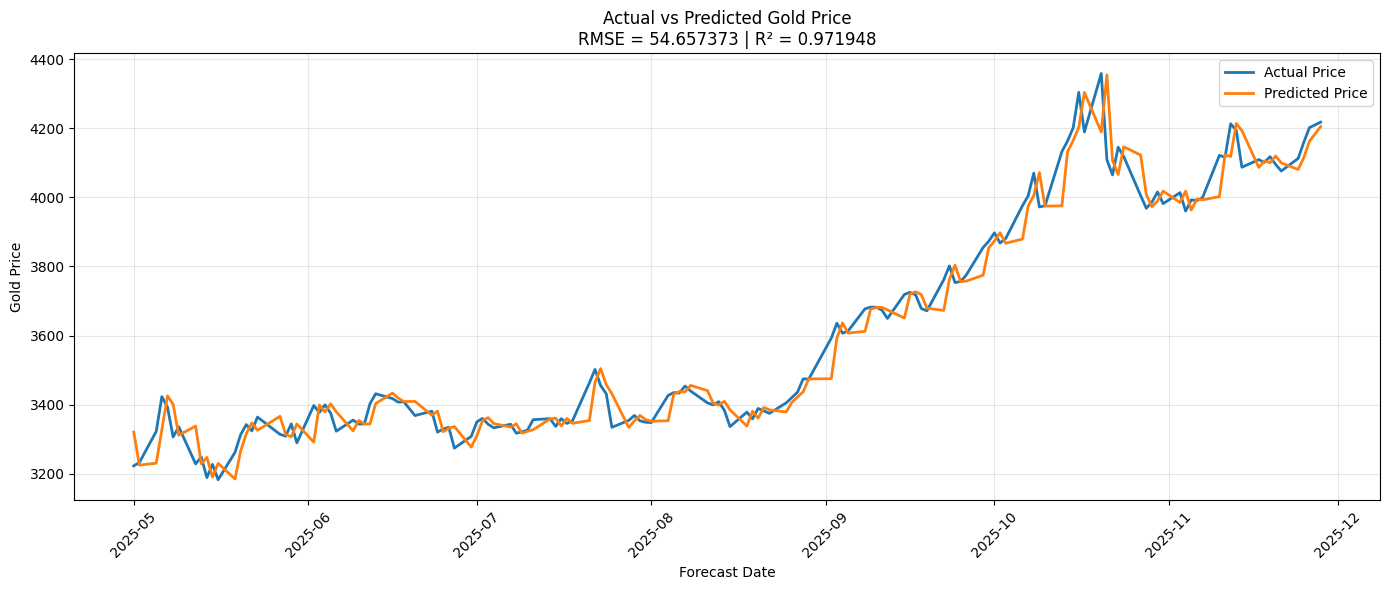

In [ ]:
results_df, combined_work_df = build_simulation_table(
    historical_df=historical_df,
    new_df=new_df,
    metadata=metadata,
    x_scaler=x_scaler,
    y_scaler=y_scaler,
    model=model,
)

sim_results, sim_metrics = evaluate_window(results_df, SIM_START, SIM_END)

print("Simulation metrics:")
print(json.dumps(sim_metrics, indent=4))

display(sim_results.head())
display(sim_results.tail())

# =========================
# Extra metrics for selected simulation window
# =========================
if sim_results.empty:
    print("No rows found in the selected simulation window.")
else:
    rmse_sim = np.sqrt(mean_squared_error(sim_results["actual_price"], sim_results["predicted_price"]))
    r2_sim = r2_score(sim_results["actual_price"], sim_results["predicted_price"])
    mae_sim = mean_absolute_error(sim_results["actual_price"], sim_results["predicted_price"])

    print(f"\nWindow RMSE: {rmse_sim:.6f}")
    print(f"Window MAE : {mae_sim:.6f}")
    print(f"Window R²  : {r2_sim:.6f}")

    # =========================
    # Actual vs Predicted Plot
    # =========================
    plt.figure(figsize=(14, 6))
    plt.plot(
        sim_results["forecast_date"],
        sim_results["actual_price"],
        label="Actual Price",
        linewidth=2
    )
    plt.plot(
        sim_results["forecast_date"],
        sim_results["predicted_price"],
        label="Predicted Price",
        linewidth=2
    )

    plt.title(
        f"Actual vs Predicted Gold Price\n"
        f"RMSE = {rmse_sim:.6f} | R² = {r2_sim:.6f}"
    )
    plt.xlabel("Forecast Date")
    plt.ylabel("Gold Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 8) Optional: save the simulation results to CSV

In [ ]:
SAVE_RESULTS = True
RESULTS_OUTPUT_PATH = os.path.join(BASE_DIR, "gold_newdata_simulation_results.csv")

if SAVE_RESULTS:
    results_df.to_csv(RESULTS_OUTPUT_PATH, index=False)
    print("Saved:", RESULTS_OUTPUT_PATH)
else:
    print("Saving skipped.")

Saved: /content/drive/MyDrive/IPYNB SIMULATION/models/gold_RRL_interpolate/seed_2/gold_newdata_simulation_results.csv


## Important note

This notebook is built for the **PyTorch training pipeline** you shared, not for the older TensorFlow/Keras simulation notebook.

That matters because your training code:

1. computes `pct_change()` for the numeric columns  
2. predicts **next-step return**  
3. reconstructs the absolute next-day gold price from `P_t_abs * (1 + predicted_return)`

So this notebook keeps that same logic.